# Modeling – Variance Threshold + Random Forest – John Bouckaert & Hugo Fiévet

## Introduction

Dans ce notebook, nous appliquons le modèle Random Forest au jeu de données issu de la sélection de variables réalisée avec la méthode `Variance Threshold`.

L’objectif est d’évaluer les performances de cette combinaison en suivant une démarche complète : choix d’un indicateur pertinent, entraînement du modèle, optimisation des hyperparamètres, validation croisée, analyse du surapprentissage éventuel et interprétation des résultats.

Cette combinaison permettra de comparer l’effet d’une sélection automatique fondée sur la variance avec un modèle d’ensemble plus puissant.

## Table of contents

1. [Loading the selected datasets](#1-loading-the-selected-datasets)  
2. [Choice of the performance metric](#2-choice-of-the-performance-metric)  
3. [Baseline Random Forest model](#3-baseline-random-forest-model)  
4. [Hyperparameter tuning with GridSearchCV](#4-hyperparameter-tuning-with-gridsearchcv)  
5. [Cross-validation and performance evaluation](#5-cross-validation-and-performance-evaluation)  
6. [Overfitting and underfitting analysis](#6-overfitting-and-underfitting-analysis)  
7. [Conclusion](#conclusion)
8. [General conclusion](#general-conclusion)

## 1. Loading the selected datasets

Dans cette première étape, nous chargeons les jeux de données correspondant à la sélection de variables obtenue avec `Variance Threshold`.

L’objectif est de vérifier que les dimensions des jeux d’entraînement et de test sont cohérentes avant de commencer la modélisation avec le modèle Random Forest.

In [ ]:
import pandas as pd

# Chargement des jeux de données sélectionnés
X_train = pd.read_csv("xtrain_VT.csv")
X_test = pd.read_csv("xtest_VT.csv")
y_train = pd.read_csv("ytrain.csv")
y_test = pd.read_csv("ytest.csv")

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test :", X_test.shape)
print("Dimensions de y_train :", y_train.shape)
print("Dimensions de y_test :", y_test.shape)

print("\nColonnes de X_train :")
print(X_train.columns.tolist())

print("\nAperçu de X_train :")
print(X_train.head())

Dimensions de X_train : (1047, 20)
Dimensions de X_test : (262, 20)
Dimensions de y_train : (1047, 1)
Dimensions de y_test : (262, 1)

Colonnes de X_train :
['age', 'sibsp', 'parch', 'fare', 'has_cabin', 'family_size', 'pclass_1', 'pclass_2', 'pclass_3', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'title_grouped_Miss', 'title_grouped_Mr', 'title_grouped_Mrs', 'family_group_alone', 'family_group_large_family', 'family_group_small_family']

Aperçu de X_train :
        age     sibsp     parch      fare  has_cabin  family_size  pclass_1  \
0 -0.820265 -0.479571 -0.447597 -0.499246          0    -0.557940         0   
1 -0.371539  0.510785 -0.447597 -0.090614          0     0.083293         0   
2 -1.343779  3.481854  1.872374 -0.017890          0     3.289456         0   
3 -0.296752 -0.479571 -0.447597 -0.509988          0    -0.557940         0   
4 -0.969840 -0.479571 -0.447597 -0.501292          0    -0.557940         0   

   pclass_2  pclass_3  sex_female  sex

Les fichiers correspondant à la sélection obtenue par `Variance Threshold` ont bien été chargés et leurs dimensions sont cohérentes. Le jeu d’entraînement contient **1047 observations** et **20 variables**, tandis que le jeu de test contient **262 observations** et les mêmes **20 variables**. Les variables cibles `y_train` et `y_test` ont également été récupérées correctement.

La liste des colonnes confirme que cette combinaison repose sur un ensemble de variables relativement large, comprenant à la fois des variables quantitatives standardisées et plusieurs variables binaires issues de l’encodage catégoriel. Cette sélection conserve plus d’information que `SelectKBest`, tout en éliminant les variables les moins dispersées.

L’aperçu de `X_train` montre que le jeu de données utilisé pour cette modélisation est propre, homogène et prêt à être soumis au modèle Random Forest. La prochaine étape consiste à rappeler l’indicateur de performance principal retenu pour évaluer cette combinaison.

## 2. Choice of the performance metric

**Dans ce notebook, nous choisissons le F1-score comme indicateur principal de performance.**

Ce choix s’explique par le fait que la variable cible n’est pas parfaitement équilibrée : la proportion de passagers non survivants est plus élevée que celle des survivants. Dans ce contexte, l’accuracy seule pourrait donner une vision trop simplifiée des performances du modèle.

Le F1-score constitue un compromis entre la précision et le rappel. Il permet donc de mieux évaluer la capacité du modèle à identifier correctement les survivants tout en limitant les erreurs de classification. Cet indicateur est particulièrement pertinent lorsque l’on souhaite tenir compte à la fois des faux positifs et des faux négatifs.

## 3. Baseline Random Forest model

Dans cette étape, nous entraînons un premier modèle Random Forest avec des paramètres simples afin d’obtenir une référence de départ.

L’objectif est d’évaluer les performances initiales du modèle avant toute optimisation des hyperparamètres. Cette première évaluation servira de point de comparaison pour la suite du notebook.

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# y sous forme de vecteur
y_train_series = y_train.iloc[:, 0]
y_test_series = y_test.iloc[:, 0]

# Modèle Random Forest de base
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train, y_train_series)

# Prédictions
y_pred_baseline = rf_baseline.predict(X_test)

# Évaluation
accuracy_baseline = accuracy_score(y_test_series, y_pred_baseline)
f1_baseline = f1_score(y_test_series, y_pred_baseline)

print("Accuracy du modèle Random Forest de base :", round(accuracy_baseline, 4))
print("F1-score du modèle Random Forest de base :", round(f1_baseline, 4))

print("\nMatrice de confusion :")
print(confusion_matrix(y_test_series, y_pred_baseline))

print("\nClassification report :")
print(classification_report(y_test_series, y_pred_baseline))

Accuracy du modèle Random Forest de base : 0.7863
F1-score du modèle Random Forest de base : 0.7255

Matrice de confusion :
[[132  30]
 [ 26  74]]

Classification report :
              precision    recall  f1-score   support

           0       0.84      0.81      0.82       162
           1       0.71      0.74      0.73       100

    accuracy                           0.79       262
   macro avg       0.77      0.78      0.78       262
weighted avg       0.79      0.79      0.79       262



Le modèle Random Forest de base obtient une **accuracy de 0.7863** et un **F1-score de 0.7255** sur le jeu de test. Ces résultats sont corrects, mais ils restent pour l’instant légèrement inférieurs à ceux obtenus avec la combinaison `P + Random Forest`.

La matrice de confusion indique que le modèle classe correctement **132 non-survivants** et **74 survivants**. En revanche, il commet **30 faux positifs** et **26 faux négatifs**, ce qui montre qu’il fait encore un nombre non négligeable d’erreurs dans les deux classes.

Le rapport de classification confirme cette performance intermédiaire. Pour la classe `0`, le rappel est de **0.81**, tandis que pour la classe `1`, il est de **0.74**. Le **F1-score de la classe des survivants** atteint **0.73**, ce qui constitue un résultat satisfaisant mais encore perfectible.

Dans l’ensemble, ce premier modèle Random Forest fournit une base correcte pour cette combinaison. Les performances sont acceptables, mais une optimisation des hyperparamètres semble nécessaire afin d’exploiter davantage le potentiel du modèle.

## 4. Hyperparameter tuning with GridSearchCV

Dans cette étape, nous cherchons à améliorer les performances du modèle Random Forest en optimisant ses principaux hyperparamètres.

Nous utilisons `GridSearchCV` afin de tester automatiquement plusieurs combinaisons de paramètres et d’identifier celle qui maximise le **F1-score** en validation croisée. Cette démarche permet de contrôler la complexité du modèle et de limiter le risque de surapprentissage.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Grille d'hyperparamètres
param_grid = {
    "n_estimators": [100, 200], # nombre d’arbres dans la forêt
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}

# GridSearchCV
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train_series)

print("Meilleurs hyperparamètres :")
print(grid_rf.best_params_)

print("\nMeilleur F1-score moyen en validation croisée :")
print(round(grid_rf.best_score_, 4))

results_rf = pd.DataFrame(grid_rf.cv_results_)
results_rf = results_rf.sort_values(by="rank_test_score").reset_index(drop=True)

print("\nTop 10 des combinaisons testées :")
print(results_rf[[
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].head(10))

Meilleurs hyperparamètres :
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

Meilleur F1-score moyen en validation croisée :
0.7352

Top 10 des combinaisons testées :
                                              params  mean_test_score  \
0  {'max_depth': 5, 'max_features': 'sqrt', 'min_...         0.735198   
1  {'max_depth': 5, 'max_features': 'log2', 'min_...         0.735198   
2  {'max_depth': 5, 'max_features': 'log2', 'min_...         0.732617   
3  {'max_depth': 5, 'max_features': 'sqrt', 'min_...         0.732617   
4  {'max_depth': 5, 'max_features': 'log2', 'min_...         0.732306   
5  {'max_depth': 5, 'max_features': 'log2', 'min_...         0.732306   
6  {'max_depth': 5, 'max_features': 'sqrt', 'min_...         0.732306   
7  {'max_depth': 5, 'max_features': 'sqrt', 'min_...         0.732306   
8  {'max_depth': 5, 'max_features': 'sqrt', 'min_...         0.732306   
9  {'max_depth': 5, 'max_features': 'log2

La recherche par grille montre que la meilleure combinaison d’hyperparamètres est obtenue avec **100 arbres**, une profondeur maximale de **5**, `min_samples_split = 10`, `min_samples_leaf = 1` et `max_features = "sqrt"`. Ce résultat suggère qu’une forêt de profondeur modérée, avec une contrainte un peu plus forte sur les divisions internes, généralise mieux qu’une forêt plus complexe sur ce dataset.

Le meilleur **F1-score moyen en validation croisée** est de **0.7352**. Ce score est supérieur à celui du modèle de base et montre que l’optimisation améliore la qualité de la combinaison `VT + Random Forest`.

On remarque également que plusieurs combinaisons obtiennent des scores très proches, ce qui indique une certaine stabilité des performances autour des meilleurs réglages. La profondeur maximale de `5` apparaît ici encore comme un paramètre important : elle permet de limiter la complexité des arbres tout en conservant une bonne capacité de discrimination.

## 5. Performance evaluation

Dans cette étape, nous évaluons sur le jeu de test le meilleur modèle Random Forest obtenu par optimisation.

L’objectif est de comparer ses performances à celles du modèle de base, en utilisant les mêmes indicateurs : accuracy, F1-score, matrice de confusion et rapport de classification.

In [ ]:
# Meilleur modèle trouvé par GridSearchCV
best_rf = grid_rf.best_estimator_

# Prédictions sur le jeu de test
y_pred_best = best_rf.predict(X_test)

# Scores
accuracy_best = accuracy_score(y_test_series, y_pred_best)
f1_best = f1_score(y_test_series, y_pred_best)

print("Accuracy du meilleur modèle Random Forest :", round(accuracy_best, 4))
print("F1-score du meilleur modèle Random Forest :", round(f1_best, 4))

print("\nMatrice de confusion :")
print(confusion_matrix(y_test_series, y_pred_best))

print("\nClassification report :")
print(classification_report(y_test_series, y_pred_best))

print("\nRappel des performances du modèle de base :")
print("Accuracy baseline :", round(accuracy_baseline, 4))
print("F1-score baseline :", round(f1_baseline, 4))

Accuracy du meilleur modèle Random Forest : 0.8473
F1-score du meilleur modèle Random Forest : 0.7959

Matrice de confusion :
[[144  18]
 [ 22  78]]

Classification report :
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       162
           1       0.81      0.78      0.80       100

    accuracy                           0.85       262
   macro avg       0.84      0.83      0.84       262
weighted avg       0.85      0.85      0.85       262


Rappel des performances du modèle de base :
Accuracy baseline : 0.7863
F1-score baseline : 0.7255


Le meilleur modèle Random Forest obtenu par `GridSearchCV` améliore nettement les performances du modèle de base. L’**accuracy** passe de **0.7863** à **0.8473**, tandis que le **F1-score** progresse de **0.7255** à **0.7959**. L’optimisation des hyperparamètres apporte donc ici un gain clair et significatif.

La matrice de confusion montre que le modèle classe correctement **144 non-survivants** et **78 survivants**. Par rapport au modèle de base, le nombre de faux négatifs diminue de **26 à 22**, tandis que le nombre de faux positifs diminue aussi de **30 à 18**. L’amélioration porte donc sur les deux classes, ce qui rend le modèle plus équilibré.

Le rapport de classification confirme cette progression. Pour la classe `1`, le **rappel** passe de **0.74** à **0.78**, et le **F1-score** passe de **0.73** à **0.80**. Le modèle devient donc plus efficace pour identifier les survivants tout en conservant de très bonnes performances sur la classe des non-survivants.

Dans l’ensemble, cette combinaison `VT + Random Forest` devient très performante après optimisation. Elle se place parmi les meilleures combinaisons obtenues jusqu’à présent, avec des résultats très proches des meilleurs modèles déjà observés.

## 6. Overfitting and underfitting analysis

Dans cette étape, nous comparons les performances du meilleur modèle sur le jeu d’entraînement et sur le jeu de test afin d’évaluer la présence éventuelle de surapprentissage ou de sous-apprentissage.

L’objectif est de vérifier si le modèle généralise correctement, ou s’il obtient des performances trop élevées sur les données d’entraînement par rapport aux données de test.

In [5]:
# Prédictions sur le jeu d'entraînement
y_pred_train = best_rf.predict(X_train)

# Scores sur le train
accuracy_train = accuracy_score(y_train_series, y_pred_train)
f1_train = f1_score(y_train_series, y_pred_train)

print("Performance du meilleur modèle sur le jeu d'entraînement :")
print("Accuracy train :", round(accuracy_train, 4))
print("F1-score train :", round(f1_train, 4))

print("\nPerformance du meilleur modèle sur le jeu de test :")
print("Accuracy test  :", round(accuracy_best, 4))
print("F1-score test  :", round(f1_best, 4))

print("\nÉcart entre train et test :")
print("Écart accuracy :", round(accuracy_train - accuracy_best, 4))
print("Écart F1-score :", round(f1_train - f1_best, 4))

Performance du meilleur modèle sur le jeu d'entraînement :
Accuracy train : 0.8195
F1-score train : 0.7555

Performance du meilleur modèle sur le jeu de test :
Accuracy test  : 0.8473
F1-score test  : 0.7959

Écart entre train et test :
Écart accuracy : -0.0278
Écart F1-score : -0.0404


L’analyse des performances sur les jeux d’entraînement et de test ne met pas en évidence de surapprentissage. En effet, si le modèle surapprenait, on s’attendrait à observer des scores nettement meilleurs sur le jeu d’entraînement que sur le jeu de test. Or ici, c’est l’inverse : le modèle obtient une **accuracy de 0.8195** et un **F1-score de 0.7555** sur le jeu d’entraînement, contre **0.8473** et **0.7959** sur le jeu de test.

Les écarts observés sont donc négatifs, aussi bien pour l’accuracy (**-0.0278**) que pour le F1-score (**-0.0404**). Cela signifie que la forêt aléatoire retenue ne mémorise pas excessivement les données d’entraînement. Ce comportement est cohérent avec les hyperparamètres sélectionnés, en particulier une profondeur maximale limitée à `5` et une valeur de `min_samples_split = 10`, qui contribuent à contrôler la complexité du modèle.

Le fait que les performances soient légèrement meilleures sur le jeu de test que sur le jeu d’entraînement peut sembler surprenant, mais ce n’est pas impossible. Cela peut simplement indiquer que le découpage train/test utilisé ici rend le jeu de test un peu plus favorable au modèle que certaines partitions internes du jeu d’entraînement. Ce résultat ne traduit donc pas un problème méthodologique évident.

Dans l’ensemble, ce comportement suggère plutôt un modèle qui généralise correctement. Il ne semble ni fortement surapprendre, ni présenter un sous-apprentissage manifeste, puisque les performances restent satisfaisantes sur le jeu de test après optimisation.

### Learning curve

Afin de compléter l’analyse du surapprentissage et du sous-apprentissage, nous utilisons une courbe d’apprentissage.  
Cette représentation permet d’observer l’évolution des performances du modèle sur le jeu d’entraînement et en validation croisée en fonction de la quantité de données utilisées.

L’objectif est de vérifier si le modèle bénéficie encore d’un apport de données supplémentaires, et d’identifier plus finement un éventuel surapprentissage ou sous-apprentissage.

Résultats de la courbe d'apprentissage :
   train_size  f1_train_mean  f1_train_std  f1_validation_mean  \
0          83         0.7831        0.0478              0.6707   
1         167         0.7953        0.0172              0.6739   
2         251         0.7666        0.0076              0.6847   
3         334         0.7578        0.0054              0.6828   
4         418         0.7778        0.0087              0.6869   
5         502         0.7754        0.0156              0.7139   
6         585         0.7769        0.0164              0.6976   
7         669         0.7721        0.0082              0.7191   
8         753         0.7701        0.0084              0.7234   
9         837         0.7609        0.0075              0.7352   

   f1_validation_std  
0             0.0456  
1             0.0427  
2             0.0489  
3             0.0376  
4             0.0469  
5             0.0449  
6             0.0394  
7             0.0429  
8             0.0433  
9 

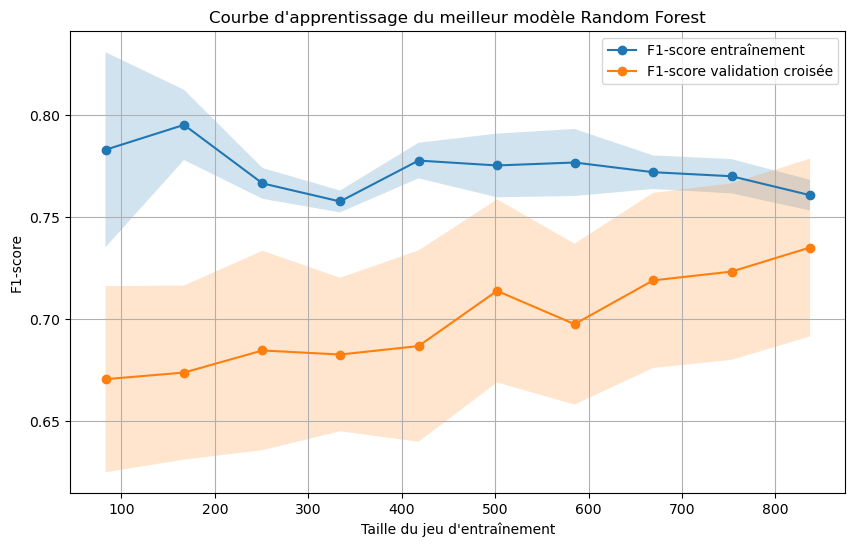

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Calcul de la courbe d'apprentissage
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_rf,
    X=X_train,
    y=y_train_series,
    cv=5,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Moyennes et écarts-types
train_scores_mean = train_scores.mean(axis=1)
train_scores_std = train_scores.std(axis=1)

val_scores_mean = val_scores.mean(axis=1)
val_scores_std = val_scores.std(axis=1)

# Tableau des résultats
learning_curve_df = pd.DataFrame({
    "train_size": train_sizes,
    "f1_train_mean": train_scores_mean,
    "f1_train_std": train_scores_std,
    "f1_validation_mean": val_scores_mean,
    "f1_validation_std": val_scores_std
})

print("Résultats de la courbe d'apprentissage :")
print(learning_curve_df.round(4))

# Graphique
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, marker="o", label="F1-score entraînement")
plt.plot(train_sizes, val_scores_mean, marker="o", label="F1-score validation croisée")

plt.fill_between(
    train_sizes,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_scores_mean - val_scores_std,
    val_scores_mean + val_scores_std,
    alpha=0.2
)

plt.title("Courbe d'apprentissage du meilleur modèle Random Forest")
plt.xlabel("Taille du jeu d'entraînement")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True)
plt.show()

La courbe d’apprentissage montre que le modèle Random Forest progresse lorsque la taille du jeu d’entraînement augmente, puis tend à se stabiliser. Pour les plus petites tailles d’échantillon, les performances sont plus instables, comme le montrent les écarts-types plus élevés au début de la courbe. Cela est particulièrement visible pour `train_size = 83`, où les scores varient encore sensiblement d’un pli de validation à l’autre.

Lorsque la taille du jeu d’entraînement augmente, le **F1-score sur l’entraînement** et le **F1-score en validation croisée** se rapprochent progressivement. À partir d’environ **650 à 850 observations**, les deux courbes deviennent relativement stables, avec un F1-score d’entraînement proche de **0.76 à 0.77** et un F1-score de validation croisée compris entre **0.72 et 0.74**.

L’écart entre les deux courbes reste modéré sur la fin, ce qui ne suggère pas de surapprentissage important. Si la forêt aléatoire surapprenait fortement, la courbe d’entraînement resterait nettement au-dessus de la courbe de validation. Ici, les deux courbes convergent progressivement, ce qui confirme que le modèle généralise correctement.

On n’observe pas non plus de sous-apprentissage manifeste. Les scores finaux restent corrects et cohérents avec les performances obtenues sur le jeu de test. Le modèle semble donc atteindre un compromis satisfaisant entre apprentissage et généralisation.

Enfin, la fin de la courbe laisse penser que l’ajout de nouvelles données pourrait encore apporter une légère amélioration, mais sans changement majeur. Le modèle semble déjà proche de son niveau de performance stable pour cette combinaison de variables et d’hyperparamètres.

## Conclusion

Dans ce notebook, nous avons évalué la combinaison entre la sélection de variables obtenue par `Variance Threshold` et le modèle `Random Forest`.

Le modèle de base a d’abord fourni des résultats corrects, puis l’optimisation des hyperparamètres par `GridSearchCV` a permis une amélioration nette des performances. Le meilleur modèle obtenu utilise **100 arbres**, une profondeur maximale de **5**, `min_samples_split = 10`, `min_samples_leaf = 1` et `max_features = "sqrt"`. Sur le jeu de test, ce modèle atteint une **accuracy de 0.8473** et un **F1-score de 0.7959**, ce qui constitue une amélioration claire par rapport à la forêt aléatoire de base.

L’analyse des performances sur les jeux d’entraînement et de test, ainsi que la courbe d’apprentissage, ne mettent pas en évidence de surapprentissage important. Le modèle semble généraliser correctement, ce qui s’explique notamment par une profondeur limitée et par un contrôle des conditions de division des nœuds.

Cette combinaison `VT + Random Forest` constitue donc une solution très performante pour la prédiction de la survie des passagers du Titanic. Elle se place parmi les meilleures combinaisons obtenues dans ce travail et pourra être comparée aux autres résultats dans le fichier récapitulatif final.

## General conclusion

L’ensemble du travail montre que la performance finale ne dépend pas uniquement du choix du modèle, mais aussi de la manière dont les variables sont construites, transformées et sélectionnées. Une étape de feature engineering bien pensée peut modifier sensiblement la qualité d’une modélisation. Le cas de `family_group` l’illustre bien : la structure familiale s’est révélée plus informative lorsqu’elle était représentée sous forme de groupes que lorsqu’elle était réduite à une simple variable numérique.

Les comparaisons entre modèles montrent également qu’il n’existe pas de hiérarchie absolue entre les méthodes. Plusieurs combinaisons aboutissent à des résultats très proches, et certaines obtiennent même la même accuracy tout en produisant des prédictions différentes. Cela montre qu’il faut rester prudent avant de désigner un « meilleur modèle » uniquement sur un score. Dans ce travail, le modèle `KB + Decision Tree` est retenu comme meilleur modèle final sur la base du F1-score, mais l’écart avec `VT + Random Forest` et `P + Random Forest` reste limité. Le classement final dépend donc aussi du critère choisi.

Une autre réflexion importante concerne l’interprétation des variables les plus prédictives. Les variables les plus performantes sont souvent liées au sexe, à la classe, au titre, au tarif ou à la cabine. Cela suggère que le modèle apprend en grande partie la structure sociale présente dans les données du Titanic. En ce sens, il prédit efficacement la survie, mais ces résultats ne doivent pas être interprétés comme des relations causales simples. Le modèle capte surtout des inégalités historiques déjà inscrites dans le dataset.

Enfin, ce travail montre que les méthodes automatiques de sélection et l’analyse exploratoire ne jouent pas exactement le même rôle. Dans nos résultats, le meilleur modèle final est obtenu avec une sélection automatique (`SelectKBest`) combinée à un arbre de décision. Il ne serait donc pas juste d’affirmer que la sélection personnelle est la plus performante.

En revanche, l’analyse descriptive reste importante en amont, notamment pour le feature engineering et pour l’interprétation des variables. Le cas de `family_group` l’illustre bien : cette variable n’est pas issue d’une méthode automatique, mais d’une réflexion menée à partir de l’analyse exploratoire, et elle apparaît ensuite dans plusieurs combinaisons performantes. On peut donc dire que les méthodes automatiques ont donné les meilleurs résultats finaux, mais qu’elles ont été appliquées sur un jeu de variables déjà enrichi par une réflexion analytique.